# ルーレットシミュレーター

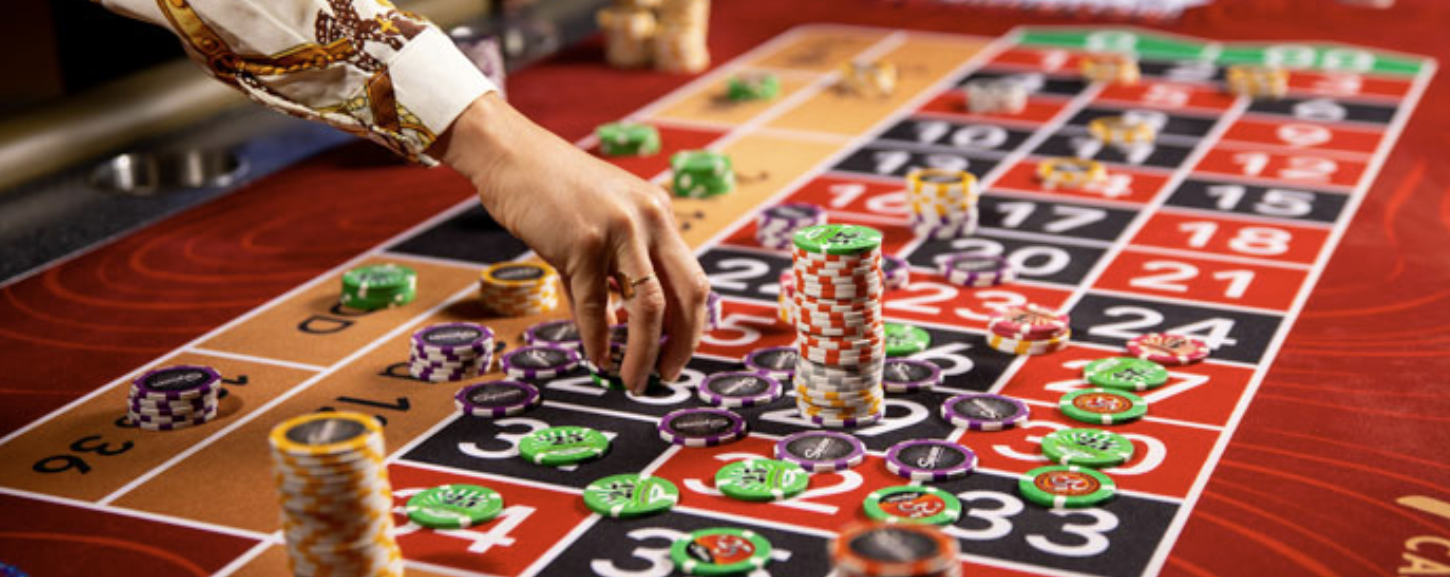
以下のアプリは、大数の法則を示しています... ルーレットのスピンをシミュレートすることで、最終的には... 常にハウスが勝つことを示します。プレイすればするほど、ハウスに勝つ「緑」のエリアに入る可能性は低くなります！

しかし、あなたが幸運な一人かもしれません。試してみてください！

In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.ticker as ticker

# Set the font family to a Japanese font
plt.rcParams['font.family'] = 'Hiragino Sans'  # You can change this to any Japanese font available on your system


In [2]:
# チャートを更新する関数
def update_chart():
    clear_output(wait=True)
    plt.figure(figsize=(12, 6))
    
    # 累積収益の線を描画
    plt.plot(results, color='b', linestyle='-', linewidth=1, alpha=0.5, label='累積収益')
    
    # 勝ち負けのマーカーを個別に描画
    if len(log) > 0:
        for i, entry in enumerate(log):
            if entry['収益'] == 1:  # 勝ち
                plt.scatter(i, results[i], color='green', marker='o', s=50, 
                           edgecolors='darkgreen', linewidth=1, zorder=5, alpha=0.8)
            else:  # 負け
                plt.scatter(i, results[i], color='red', marker='x', s=50, 
                           linewidth=2, zorder=5, alpha=0.8)
    
    plt.title(f'累積収益の推移 (ハウスエッジ: {house_edge*100:.2f}%)')
    plt.xlabel('ベット数')
    plt.ylabel('累積収益')
    
    # x軸とy軸の範囲を動的に調整
    current_x_max = max(50, len(results))
    if len(results) > 0:
        current_y_min = min(-10, min(results) - 5, expected_value_per_spin * len(results) - 5)
        current_y_max = max(10, max(results) + 5)
    else:
        current_y_min = -10
        current_y_max = 10
    
    plt.xlim(0, current_x_max)
    plt.ylim(current_y_min, current_y_max)
    
    # y軸のグリッドラインを1単位ごとに設定
    plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
    plt.grid(True, which='both', axis='y', alpha=0.3)
    plt.grid(True, which='both', axis='x', alpha=0.3)
    
    # ゼロ水平線を赤色に設定
    plt.axhline(0, color='orange', linewidth=2, linestyle='--', label='損益分岐点 (0)', zorder=3)
    
    # ゼロラインの下に薄い赤色の背景を追加（ハウスが勝っている領域）
    if len(results) > 0:
        plt.fill_between(range(len(results)), results, 0, where=[y < 0 for y in results], 
                        color='lightcoral', alpha=0.3, label='ハウスが勝っている')
        
        # ゼロラインの上に薄い緑色の背景を追加（プレイヤーが勝っている領域）
        plt.fill_between(range(len(results)), results, 0, where=[y > 0 for y in results], 
                        color='lightgreen', alpha=0.3, label='プレイヤーが勝っている')
        
        # 期待値の線を追加（累積期待値）
        expected_line = [expected_value_per_spin * (i + 1) for i in range(len(results))]
        plt.plot(expected_line, color='purple', linestyle='--', linewidth=2, 
                label=f'理論的期待値 (E[X] = {expected_value_per_spin:.4f}/スピン)', zorder=2)
        
        # 期待値のラベルを右端に追加
        plt.text(len(results) - 1, expected_line[-1], 
                f'期待累積: {expected_line[-1]:.2f}', 
                fontsize=9, 
                verticalalignment='bottom' if expected_line[-1] < 0 else 'top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))
        
        # 実際の結果のラベルも追加
        result_color = 'green' if results[-1] > 0 else 'red'
        status_text = 'プレイヤー勝ち!' if results[-1] > 0 else 'ハウス勝ち!'
        plt.text(len(results) - 1, results[-1], 
                f'{status_text}\n実際: {results[-1]}', 
                fontsize=9, 
                verticalalignment='top' if results[-1] < 0 else 'bottom',
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=result_color, alpha=0.5))
    
    # カスタム凡例を作成
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='b', linewidth=1, alpha=0.5),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', 
               markeredgecolor='darkgreen', markersize=8, linewidth=0),
        Line2D([0], [0], marker='x', color='red', markersize=8, linewidth=2),
        Line2D([0], [0], color='orange', linewidth=2, linestyle='--'),
        Line2D([0], [0], color='purple', linewidth=2, linestyle='--')
    ]
    
    plt.legend(custom_lines, 
              ['累積収益', '勝ち (○)', '負け (✕)', '損益分岐点', '理論的期待値'],
              loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    display(spin_button, bet_color, status_label)  # ボタンとラベルを再表示

# ...existing code...

# ログを更新する関数
def update_log():
    df = pd.DataFrame(log)
    display(df)

# ステータスを更新する関数
def update_status():
    status_label.value = f"ベット数: {len(results)}, 現在の収益: {cumulative_earnings}"

# ウィジェットの作成
bet_color = widgets.Dropdown(
    options=['red', 'black'],
    value='red',
    description='ベットカラー:',
)

spin_button = widgets.Button(
    description='ルーレットを回す',
    button_style='success',
)

status_label = widgets.Label(
    value=f"ベット数: {len(results)}, 現在の収益: {cumulative_earnings}"
)

# イベントハンドラの設定
def on_spin_button_clicked(b):
    spin_wheel(bet_color.value)

spin_button.on_click(on_spin_button_clicked)

# make another button that simulates 100 spins
def on_spin_button_clicked(b):
    for i in range(100):
        spin_wheel(bet_color.value)

spin_button.on_click(on_spin_button_clicked)

# 初期表示でボタンとラベルを表示
display(spin_button, bet_color, status_label)

NameError: name 'results' is not defined

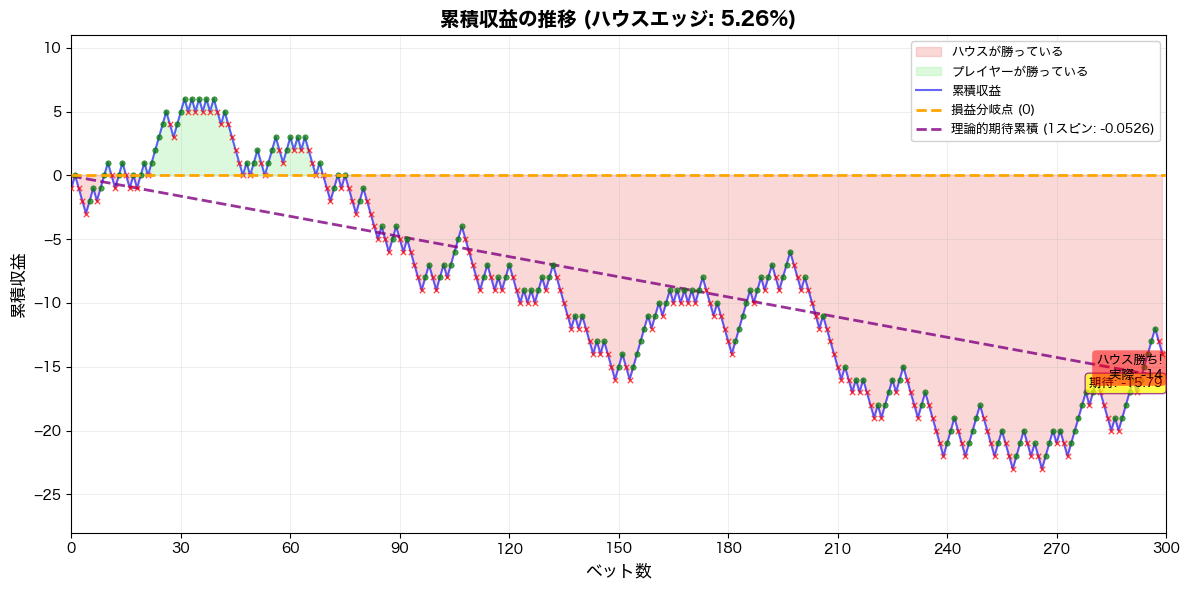

Button(button_style='success', description='🎰 ルーレットを1回回す', layout=Layout(width='200px'), style=ButtonStyle())

Button(button_style='info', description='🎰 100回連続で回す', layout=Layout(width='200px'), style=ButtonStyle())

Dropdown(description='ベットカラー:', options=('red', 'black'), style=DescriptionStyle(description_width='initial'),…

Label(value='ベット数: 295 | 現在の収益: -15 | 勝ち: 140 | 負け: 155 | 勝率: 47.5%')

In [ ]:
# 変数の初期化 - セルを実行するたびにリセット
results = []
cumulative_earnings = 0
log = []
roulette_colors = ['red', 'black', 'green']
roulette_weights = [18, 18, 2]  # アメリカンルーレット: 18赤 + 18黒 + 2緑 = 38

# 期待値とハウスエッジを計算
total_weight = sum(roulette_weights)
prob_win = roulette_weights[0] / total_weight
prob_lose = (roulette_weights[1] + roulette_weights[2]) / total_weight
expected_value_per_spin = prob_win * 1 + prob_lose * (-1)
house_edge = -expected_value_per_spin

print(f"ルーレット設定 (アメリカンルーレット):")
print(f"  赤: {roulette_weights[0]}, 黒: {roulette_weights[1]}, 緑: {roulette_weights[2]}")
print(f"  合計スロット: {total_weight}")
print(f"  勝つ確率: {prob_win:.4f} ({prob_win*100:.2f}%)")
print(f"  負ける確率: {prob_lose:.4f} ({prob_lose*100:.2f}%)")
print(f"  スピンあたりの期待値: {expected_value_per_spin:.4f} ({expected_value_per_spin*100:.2f}%)")
print(f"  ハウスエッジ: {house_edge:.4f} ({house_edge*100:.2f}%)")
print("\n")  # 改行を追加

# スピンをシミュレートする関数
def spin_wheel(bet_color, batch_mode=False):
    global cumulative_earnings
    outcome = random.choices(roulette_colors, weights=roulette_weights, k=1)[0]
    if outcome == bet_color:
        earnings = 1
    else:
        earnings = -1
    cumulative_earnings += earnings
    results.append(cumulative_earnings)
    log.append({'ベットカラー': bet_color, '結果': outcome, '収益': earnings, '累積収益': cumulative_earnings})
    
    # バッチモードでない場合のみチャート更新
    if not batch_mode:
        update_chart()
        update_status()

# チャートを更新する関数 - 最適化版
def update_chart():
    clear_output(wait=True)
    
    # 初期設定の表示を保持
    print(f"ルーレット設定 (アメリカンルーレット):")
    print(f"  赤: {roulette_weights[0]}, 黒: {roulette_weights[1]}, 緑: {roulette_weights[2]}")
    print(f"  合計スロット: {total_weight}")
    print(f"  勝つ確率: {prob_win:.4f} ({prob_win*100:.2f}%)")
    print(f"  負ける確率: {prob_lose:.4f} ({prob_lose*100:.2f}%)")
    print(f"  スピンあたりの期待値: {expected_value_per_spin:.4f} ({expected_value_per_spin*100:.2f}%)")
    print(f"  ハウスエッジ: {house_edge:.4f} ({house_edge*100:.2f}%)")
    print("\n")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if len(results) == 0:
        ax.text(0.5, 0.5, 'ルーレットを回してください', 
                ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_xlim(0, 50)
        ax.set_ylim(-10, 10)
    else:
        # x軸とy軸の範囲を動的に調整
        current_x_max = max(50, len(results))
        # 期待値の累積ラインも考慮してy軸範囲を設定
        expected_cumulative = expected_value_per_spin * len(results)
        current_y_min = min(-10, min(results) - 5, expected_cumulative - 5)
        current_y_max = max(10, max(results) + 5)
        
        # ゼロラインの下に薄い赤色の背景を追加（ハウスが勝っている領域）
        ax.fill_between(range(len(results)), results, 0, where=[y < 0 for y in results], 
                        color='lightcoral', alpha=0.3, label='ハウスが勝っている', interpolate=True)
        
        # ゼロラインの上に薄い緑色の背景を追加（プレイヤーが勝っている領域）
        ax.fill_between(range(len(results)), results, 0, where=[y > 0 for y in results], 
                        color='lightgreen', alpha=0.3, label='プレイヤーが勝っている', interpolate=True)
        
        # 累積収益の線を描画
        ax.plot(results, color='b', linestyle='-', linewidth=1.5, alpha=0.6, label='累積収益', zorder=2)
        
        # 勝ち負けのマーカーを最適化して描画（サンプリング）
        step = max(1, len(log) // 200)  # 最大200マーカーまで
        for i in range(0, len(log), step):
            entry = log[i]
            if entry['収益'] == 1:  # 勝ち
                ax.scatter(i, results[i], color='green', marker='o', s=15, 
                          edgecolors='darkgreen', linewidth=0.5, zorder=3, alpha=0.7)
            else:  # 負け
                ax.scatter(i, results[i], color='red', marker='x', s=15, 
                          linewidth=1, zorder=3, alpha=0.7)
        
        # ゼロ水平線を設定
        ax.axhline(0, color='orange', linewidth=2, linestyle='--', label='損益分岐点 (0)', zorder=4)
        
        # 期待値の累積ラインを追加（傾斜線）
        expected_line = [expected_value_per_spin * (i + 1) for i in range(len(results))]
        ax.plot(expected_line, color='purple', linestyle='--', linewidth=2, 
                label=f'理論的期待累積 (1スピン: {expected_value_per_spin:.4f})', zorder=2, alpha=0.8)
        
        # 期待値のラベルを右端に追加
        ax.text(len(results) - 1, expected_line[-1], 
               f'期待: {expected_line[-1]:.2f}', 
               fontsize=9, 
               verticalalignment='top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7, edgecolor='purple'))
        
        # 実際の結果のラベルを右端に追加
        result_color = 'green' if results[-1] > 0 else 'red'
        status_text = 'プレイヤー勝ち!' if results[-1] > 0 else 'ハウス勝ち!'
        ax.text(len(results) - 1, results[-1], 
               f'{status_text}\n実際: {results[-1]}', 
               fontsize=9, 
               verticalalignment='bottom' if results[-1] < expected_line[-1] else 'top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=result_color, alpha=0.5, edgecolor='none'))
        
        ax.set_xlim(0, current_x_max)
        ax.set_ylim(current_y_min, current_y_max)
    
    ax.set_title(f'累積収益の推移 (ハウスエッジ: {house_edge*100:.2f}%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('ベット数', fontsize=12)
    ax.set_ylabel('累積収益', fontsize=12)
    
    # グリッドの設定
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
    ax.grid(True, which='both', axis='both', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # 凡例
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()
    
    # ボタンとラベルを表示（一度だけ）
    display(spin_button, spin_100_button, bet_color, status_label)

# ステータスを更新する関数
def update_status():
    win_count = sum(1 for entry in log if entry['収益'] == 1)
    lose_count = sum(1 for entry in log if entry['収益'] == -1)
    win_rate = (win_count / len(log) * 100) if len(log) > 0 else 0
    
    status_label.value = (f"ベット数: {len(results)} | "
                         f"現在の収益: {cumulative_earnings} | "
                         f"勝ち: {win_count} | 負け: {lose_count} | "
                         f"勝率: {win_rate:.1f}%")

# ウィジェットの作成
bet_color = widgets.Dropdown(
    options=['red', 'black'],
    value='red',
    description='ベットカラー:',
    style={'description_width': 'initial'}
)

spin_button = widgets.Button(
    description='🎰 ルーレットを1回回す',
    button_style='success',
    layout=widgets.Layout(width='200px')
)

spin_100_button = widgets.Button(
    description='🎰 100回連続で回す',
    button_style='info',
    layout=widgets.Layout(width='200px')
)

status_label = widgets.Label(
    value=f"ベット数: {len(results)}, 現在の収益: {cumulative_earnings}"
)

# イベントハンドラの設定
def on_spin_button_clicked(b):
    spin_wheel(bet_color.value)

def on_spin_100_button_clicked(b):
    import time
    # 各スピンを個別にシミュレートし、5回ごとにアニメーション表示（より滑らか）
    for i in range(100):
        spin_wheel(bet_color.value, batch_mode=True)
        
        # 5回ごとにチャートを更新してスムーズなアニメーション効果
        if (i + 1) % 5 == 0 or i == 99:
            update_chart()
            update_status()
            time.sleep(0.05)  # より短い待機時間で滑らかなアニメーション
    
    # 最終更新
    update_status()

spin_button.on_click(on_spin_button_clicked)
spin_100_button.on_click(on_spin_100_button_clicked)

# 初期表示（ボタンは一度だけ表示）
update_chart()